In [1]:
%cd ..

/home/dev/workspace


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import numpy as np
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

E0603 22:40:35.350418   21998 ptx_compiler_helpers.cc:132] *** WARNING *** Invoking ptxas with version 12.4.131, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-06-03_22-16-52/saved/checkpoint-epoch100.npy",
                                                            "+experiment=vae", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [5]:
metrics

{'loss': np.float32(72434.36)}

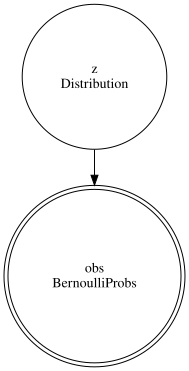

In [6]:
objects['learner'].render_model()

In [7]:
for data, target in objects['datamodule'].test_dataloader():
    recons = objects['learner'](data).reshape(data.shape[0], 1, 28, 28)
    break

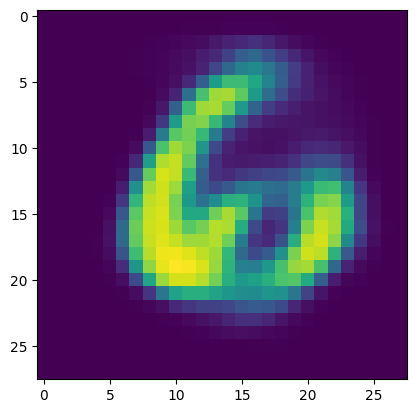

In [8]:
plt.imshow(recons[0].squeeze())

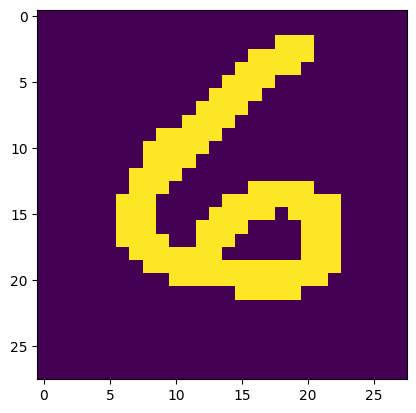

In [9]:
plt.imshow(data[0].squeeze())